In [5]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

file_path = "/content/drive/MyDrive/soil_project/soil_moisture-2020-2024.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(1827, 4)


,Date,TAVG,RAIN,TR05
0,01-01-2020,44.84,0.0,1.5570
1,02-01-2020,50.53,0.0,1.5518
2,03-01-2020,44.14,0.0,1.5556
3,04-01-2020,41.72,0.0,1.5636
4,05-01-2020,46.48,0.0,1.5643


In [9]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date")
df = df.reset_index(drop=True)
df.head()

,Date,TAVG,RAIN,TR05
0,2020-01-01,44.84,0.0,1.5570
1,2020-01-02,50.53,0.0,1.5518
2,2020-01-03,44.14,0.0,1.5556
3,2020-01-04,41.72,0.0,1.5636
4,2020-01-05,46.48,0.0,1.5643


In [10]:
features = ['TAVG', 'RAIN', 'TR05']
data = df[features].values

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data = scaler.fit_transform(data)
print(data.min(), data.max())

0.0 1.0


In [12]:
import numpy as np

def create_sequences(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 2])  # TR05
    return np.array(X), np.array(y)

X, y = create_sequences(data)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1817, 10, 3)
y shape: (1817,)


In [13]:
train_size = int(0.7 * len(X))
val_size = int(0.1 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32).to(device), \
           torch.tensor(y, dtype=torch.float32).view(-1,1).to(device)

X_train, y_train = to_tensor(X_train, y_train)
X_val, y_val = to_tensor(X_val, y_val)
X_test, y_test_tensor = to_tensor(X_test, y_test)

In [15]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=3, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


In [16]:
model = LSTMModel()
print(model)

LSTMModel(
  (lstm): LSTM(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [17]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=3,
            nhead=1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)
        self.fc = nn.Linear(3, 1)

    def forward(self, x):
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

In [18]:
model = TransformerModel()
print(model)

TransformerModel(
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=3, out_features=3, bias=True)
    )
    (linear1): Linear(in_features=3, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=3, bias=True)
    (norm1): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=3, out_features=3, bias=True)
        )
        (linear1): Linear(in_features=3, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(

/tmp/ipykernel_3003/2906903119.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)


In [19]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(3, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64, 32)

        self.transformer_layer = nn.TransformerEncoderLayer(d_model=32, nhead=2, batch_first=True)
        self.transformer = nn.TransformerEncoder(self.transformer_layer, num_layers=2)

        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)

        out = self.fc1(out)
        out = out.permute(1, 0, 2)

        out = self.transformer(out)
        out = out[-1]

        return self.fc2(out)

In [20]:
model = HybridModel()
print(model)

HybridModel(
  (lstm): LSTM(3, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (transformer_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (linear1): Linear(in_features=32, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=32, bias=True)
    (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      

In [21]:
lstm = LSTMModel().to(device)
trans = TransformerModel().to(device)
hybrid = HybridModel().to(device)

/tmp/ipykernel_3003/2906903119.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=2)


In [22]:
def train_model(model, X_train, y_train, epochs=80):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        output = model(X_train)
        loss = loss_fn(output, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return losses

In [23]:
loss_lstm = train_model(lstm, X_train, y_train)
loss_trans = train_model(trans, X_train, y_train)
loss_hybrid = train_model(hybrid, X_train, y_train)

Epoch 0, Loss: 0.7417
Epoch 5, Loss: 0.6364
Epoch 10, Loss: 0.5382
Epoch 15, Loss: 0.4414
Epoch 20, Loss: 0.3416
Epoch 25, Loss: 0.2365
Epoch 30, Loss: 0.1312
Epoch 35, Loss: 0.0517
Epoch 40, Loss: 0.0498
Epoch 45, Loss: 0.0615
Epoch 50, Loss: 0.0416
Epoch 55, Loss: 0.0405
Epoch 60, Loss: 0.0432
Epoch 65, Loss: 0.0412
Epoch 70, Loss: 0.0389
Epoch 75, Loss: 0.0391
Epoch 0, Loss: 0.9470
Epoch 5, Loss: 0.6881
Epoch 10, Loss: 0.6803
Epoch 15, Loss: 0.6557
Epoch 20, Loss: 0.6388
Epoch 25, Loss: 0.6237
Epoch 30, Loss: 0.6067
Epoch 35, Loss: 0.5896
Epoch 40, Loss: 0.5742
Epoch 45, Loss: 0.5580
Epoch 50, Loss: 0.5417
Epoch 55, Loss: 0.5262
Epoch 60, Loss: 0.5108
Epoch 65, Loss: 0.4956
Epoch 70, Loss: 0.4808
Epoch 75, Loss: 0.4661
Epoch 0, Loss: 0.8734
Epoch 5, Loss: 0.0649
Epoch 10, Loss: 0.0941
Epoch 15, Loss: 0.0858
Epoch 20, Loss: 0.0644
Epoch 25, Loss: 0.0671
Epoch 30, Loss: 0.0618
Epoch 35, Loss: 0.0587
Epoch 40, Loss: 0.0611
Epoch 45, Loss: 0.0588
Epoch 50, Loss: 0.0577
Epoch 55, Loss: 0

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model):
    model.eval()
    preds = model(X_test).detach().cpu().numpy()
    y_true = y_test

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    accuracy = (1 - mae / np.mean(y_true)) * 100

    return preds, rmse, mae, r2, accuracy

In [25]:
pred_lstm, rmse_lstm, mae_lstm, r2_lstm, acc_lstm = evaluate(lstm)
pred_trans, rmse_trans, mae_trans, r2_trans, acc_trans = evaluate(trans)
pred_hybrid, rmse_hybrid, mae_hybrid, r2_hybrid, acc_hybrid = evaluate(hybrid)

In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["LSTM", "Transformer", "Hybrid"],
    "RMSE": [rmse_lstm, rmse_trans, rmse_hybrid],
    "MAE": [mae_lstm, mae_trans, mae_hybrid],
    "R2": [r2_lstm, r2_trans, r2_hybrid],
    "Accuracy (%)": [acc_lstm, acc_trans, acc_hybrid]
})

print(results)

         Model      RMSE       MAE        R2  Accuracy (%)
0         LSTM  0.288439  0.135827  0.448978     83.273963
1  Transformer  0.635503  0.618077 -1.674841     23.888437
2       Hybrid  0.360509  0.185860  0.139214     77.112739


In [27]:
def mc_dropout(model, X, n=50):
    model.train()
    preds = []

    for _ in range(n):
        pred = model(X).detach().cpu().numpy()
        preds.append(pred)

    preds = np.array(preds)

    return preds.mean(axis=0), preds.std(axis=0)

mean, std = mc_dropout(hybrid, X_test)

In [28]:
dates = df['Date'].values
dates = dates[-len(y_test):]   # align with test set

In [29]:
mean = mean.flatten()
std = std.flatten()
y_true = y_test

In [30]:
for i in range(5):
    print(f"Date: {pd.to_datetime(dates[i]).date()} | Predicted: {mean[i]:.4f} ± {std[i]:.4f} | Actual: {y_true[i]:.4f}")

Date: 2024-01-02 | Predicted: 0.9234 ± 0.0604 | Actual: 0.9977
Date: 2024-01-03 | Predicted: 0.9389 ± 0.0666 | Actual: 0.9977
Date: 2024-01-04 | Predicted: 0.9507 ± 0.0617 | Actual: 0.9977
Date: 2024-01-05 | Predicted: 0.9127 ± 0.0761 | Actual: 0.9977
Date: 2024-01-06 | Predicted: 0.9261 ± 0.0684 | Actual: 0.9977


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_true = y_test
y_pred = mean   # use mean from MC Dropout

rmse_mc = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mc = mean_absolute_error(y_true, y_pred)
r2_mc = r2_score(y_true, y_pred)

acc_mc = (1 - mae_mc / np.mean(y_true)) * 100

print("MC Dropout Hybrid:")
print("RMSE:", rmse_mc)
print("MAE:", mae_mc)
print("R2:", r2_mc)
print("Accuracy:", acc_mc)

MC Dropout Hybrid:
RMSE: 0.35754863496913175
MAE: 0.2012032090571612
R2: 0.15329344383841637
Accuracy: 75.22331842336108


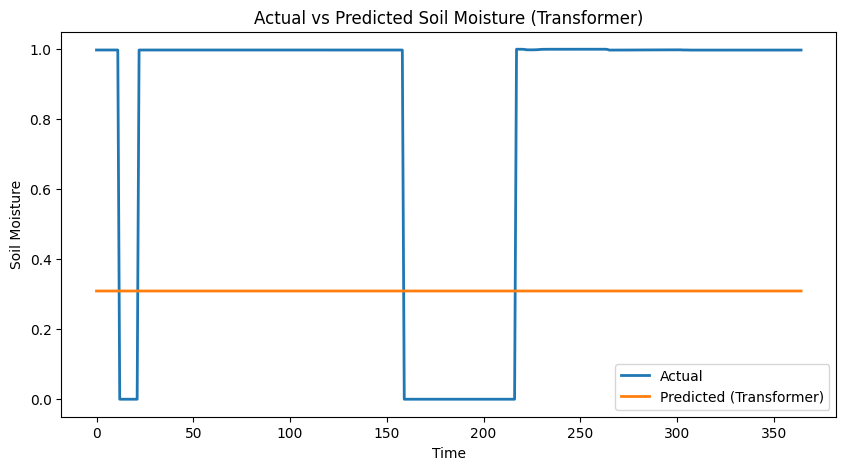

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(pred_trans, label="Predicted (Transformer)", linewidth=2)

plt.legend()
plt.title("Actual vs Predicted Soil Moisture (Transformer)")
plt.xlabel("Time")
plt.ylabel("Soil Moisture")

plt.show()

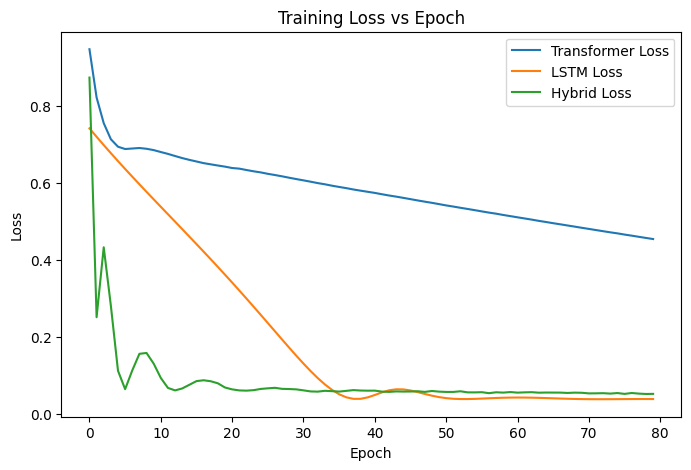

In [33]:
plt.figure(figsize=(8,5))

plt.plot(loss_trans, label="Transformer Loss")
plt.plot(loss_lstm, label="LSTM Loss")
plt.plot(loss_hybrid, label="Hybrid Loss")

plt.legend()
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

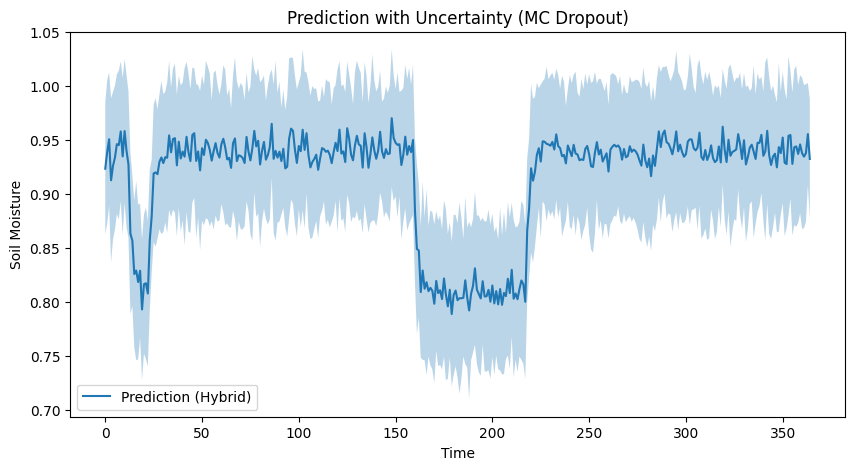

In [34]:
plt.figure(figsize=(10,5))

plt.plot(mean, label="Prediction (Hybrid)")

plt.fill_between(range(len(mean)),
                 mean.flatten() - std.flatten(),
                 mean.flatten() + std.flatten(),
                 alpha=0.3)

plt.legend()
plt.title("Prediction with Uncertainty (MC Dropout)")
plt.xlabel("Time")
plt.ylabel("Soil Moisture")

plt.show()

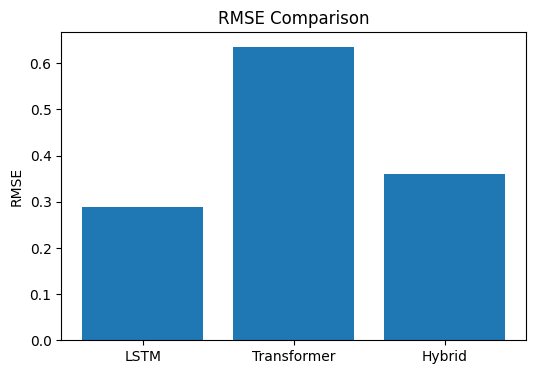

In [35]:
import numpy as np

models = ["LSTM", "Transformer", "Hybrid"]
rmse = [rmse_lstm, rmse_trans, rmse_hybrid]

plt.figure(figsize=(6,4))
plt.bar(models, rmse)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.show()